# Firearm Mortality and Gun Control Law Analysis

### Introduction
This analysis explores the relationship between firearm mortality rates across U.S. states and the strictness of firearm control laws.

Data sources:
- Firearm mortality rates from the CDC
- Gun law strictness data from Everytown
- Population data from the U.S. Census Bureau

We aim to investigate whether stricter gun control laws are associated with lower firearm mortality rates across states.


## 1. Data Collection and Preparation

### Data Sources
1. **CDC Firearm Mortality Data**: Downloaded from the CDC's open data portal using an API.
2. **Everytown Gun Control Data**: Converted gun law ratings into a 5-point Likert scale, with `5` being very strict and `1` being very lax.
3. **Population Data**: Collected from U.S. Census Bureau 2023 projections.

### Preparing the Data
The CDC data was filtered for firearm-related deaths, and population data was used to weight the mortality rates for each state.


In [1]:
# Import necessary libraries
import requests
import pandas as pd
import io
import us
import seaborn as sns
import matplotlib.pyplot as plt

# API endpoint for firearm mortality data from the CDC
url = "https://data.cdc.gov/resource/489q-934x.csv"

# Download and load the data into a DataFrame
response = requests.get(url)
data = response.content.decode('utf-8')
df = pd.read_csv(io.StringIO(data))

# Filter the data for firearm-related injuries
filtered_df = df[df['cause_of_death'] == 'Firearm-related injury']

# Extract columns corresponding to state-specific firearm mortality rates
state_columns = [col for col in filtered_df.columns if col.startswith('rate_') and not any(keyword in col for keyword in ['Type', 'Overall', 'Sex', 'Age'])]

# Function to convert state names to abbreviations using the `us` package
def get_state_abbreviation(state_name):
    state = us.states.lookup(state_name)
    return state.abbr if state else None

# Load the gun laws data
gun_laws_df = pd.read_csv("C:\\Users\\shaya\\OneDrive\\Documents\\repos\\Data608\\Story3\\Everytown-gun-laws-save-lives.csv")

# Convert the 'Strength of Gun Laws' to a 5-point Likert scale
def convert_to_likert(score):
    if score >= 80:
        return 5  # Very Strict
    elif score >= 60:
        return 4  # Strict
    elif score >= 40:
        return 3  # Moderate
    elif score >= 20:
        return 2  # Lax
    else:
        return 1  # Very Lax

gun_laws_df['Likert_Scale'] = gun_laws_df['Strength of Gun Laws (out of 100 points)'].apply(convert_to_likert)
state_gun_laws = dict(zip(gun_laws_df['Label'], gun_laws_df['Likert_Scale']))

# Load and clean the population data
pop_raw = pd.read_excel("C:/Users/shaya/OneDrive/Documents/repos/Data608/Story1/Data/NST-EST2023-POP.xlsx")
pop_data = pop_raw.iloc[8:60, [0, 5]]  # Select relevant rows and columns
pop_data.columns = ['state', '2023']
pop_data['state'] = pop_data['state'].str.replace('^\\.', '', regex=True).str.upper()
state_population = dict(zip(pop_data['state'], pop_data['2023']))


### Data Wrangling
We prepare the state-specific firearm mortality rates, gun control law strictness, and population data for further analysis.


In [21]:
# List to store results
results = []

# Iterate through the state columns and calculate mean firearm mortality rates
for state_col in state_columns:
    state_name = state_col.replace('rate_', '').replace('_', ' ').title()
    state_abbr = get_state_abbreviation(state_name)
    
    if state_abbr in state_gun_laws:
        mean_rate = filtered_df[state_col].mean()
        population = state_population.get(state_name.upper(), 0)
        results.append({
            'State': state_name,
            'Mean_Rate': mean_rate,
            'Gun_Control_Law': state_gun_laws[state_abbr],
            'Population': population
        })

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Save the results to a CSV file
#results_df.to_csv("firearm_mortality_rates.csv", index=False)

## 2. Weighted Firearm Mortality Rate by Gun Control Law Strictness

We calculate the weighted average firearm mortality rate for each Likert bin using population data.


C:\Users\shaya\AppData\Local\Temp\ipykernel_12440\4294481561.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gun_Control_Law', y='Weighted_Mean_Rate', data=weighted_results, palette="YlGnBu")


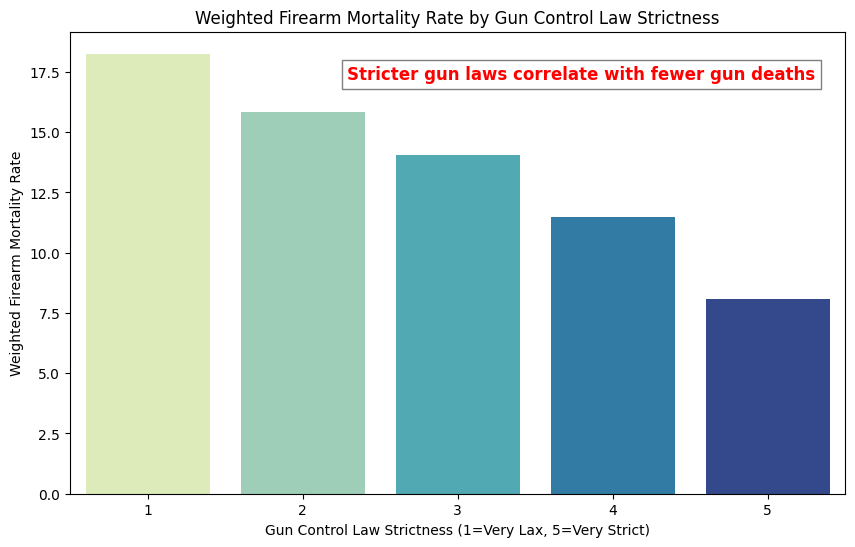

In [20]:
# Calculate weighted average for each bin
weighted_results = results_df.groupby('Gun_Control_Law').apply(lambda x: (x['Mean_Rate'] * x['Population']).sum() / x['Population'].sum()).reset_index()
weighted_results.columns = ['Gun_Control_Law', 'Weighted_Mean_Rate']

# Plot the weighted mean rates
plt.figure(figsize=(10, 6))
sns.barplot(x='Gun_Control_Law', y='Weighted_Mean_Rate', data=weighted_results, palette="YlGnBu")
plt.title("Weighted Firearm Mortality Rate by Gun Control Law Strictness")
plt.xlabel("Gun Control Law Strictness (1=Very Lax, 5=Very Strict)")
plt.ylabel("Weighted Firearm Mortality Rate")

# Add annotation with the main finding
plt.text(2.8, max(weighted_results['Weighted_Mean_Rate']) - 0.5, "Stricter gun laws correlate with fewer gun deaths", 
         color='red', fontsize=12, ha='center', va='top', weight='bold', 
         bbox=dict(facecolor='white', alpha=0.5))
plt.show()

## 3. Heatmap of Firearm Mortality Rates by State Gun Control Levels

A heatmap visualizes state-level differences in firearm mortality rates and their gun control law strictness.


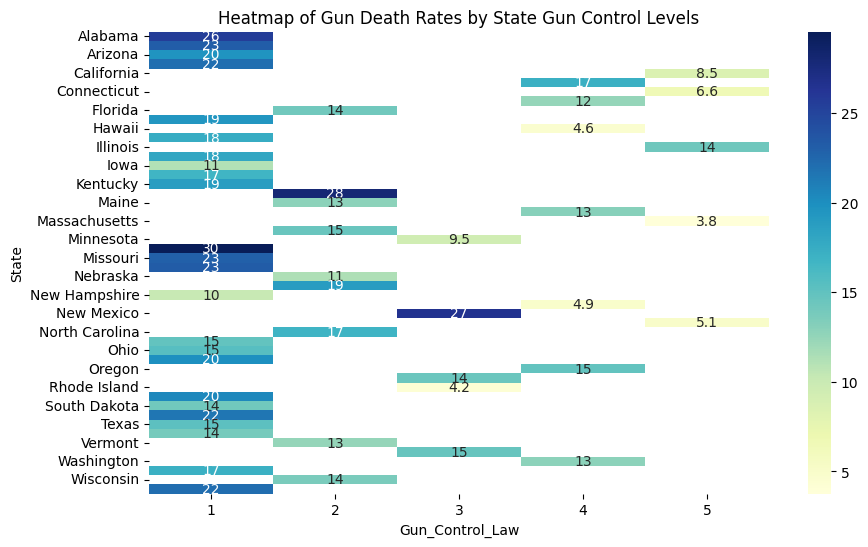

In [4]:
# Create a pivot table for heatmap
pivot_table = results_df.pivot_table(values='Mean_Rate', index='State', columns='Gun_Control_Law')

# Plot heatmap
plt.figure(figsize=(10, 6))
heatmap = sns.heatmap(pivot_table, annot=True, cmap="YlGnBu")
plt.title("Heatmap of Gun Death Rates by State Gun Control Levels")
plt.show()


## 4. Correlation Analysis: Likert Bin vs. Firearm Mortality Rate

We compute the correlation between the strictness of gun control laws and the average firearm mortality rate.


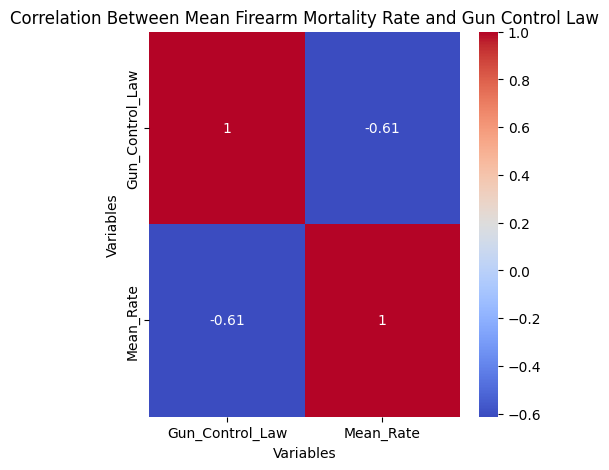

In [5]:
# Calculate correlations
correlation_matrix = results_df[['Gun_Control_Law', 'Mean_Rate']].corr()

# Prepare Heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Between Mean Firearm Mortality Rate and Gun Control Law")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.show()


## 5. Conclusion

- States with stricter gun control laws (higher Likert scores) tend to have lower firearm mortality rates.
- The correlation analysis suggests an inverse relationship between the strictness of gun laws and firearm deaths.
  
**Policy Implication**:
- This analysis provides evidence that stricter gun control laws are associated with reduced firearm mortality rates, offering insight for policymakers on the potential impact of stricter legislation.


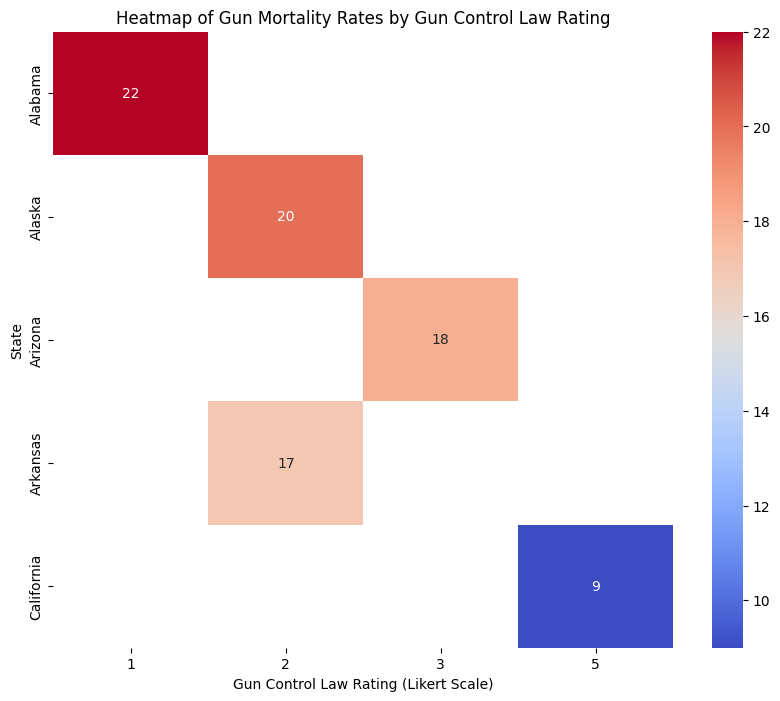

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data: Replace this with your actual data
data = {
    'State': ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California'],
    'Gun_Control_Law': [1, 2, 3, 2, 5],
    'Gun_Mortality_Rate': [22, 20, 18, 17, 9]
}

df = pd.DataFrame(data)

# Create a pivot table for the heatmap
pivot_table = df.pivot_table(values='Gun_Mortality_Rate', index='State', columns='Gun_Control_Law')

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, cmap="coolwarm", cbar=True)
plt.title('Heatmap of Gun Mortality Rates by Gun Control Law Rating')
plt.xlabel('Gun Control Law Rating (Likert Scale)')
plt.ylabel('State')
plt.show()
